In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('heart.csv')

In [3]:
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [4]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## EDA

In [5]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [6]:
data.shape

(918, 12)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [8]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

<Axes: xlabel='HeartDisease'>

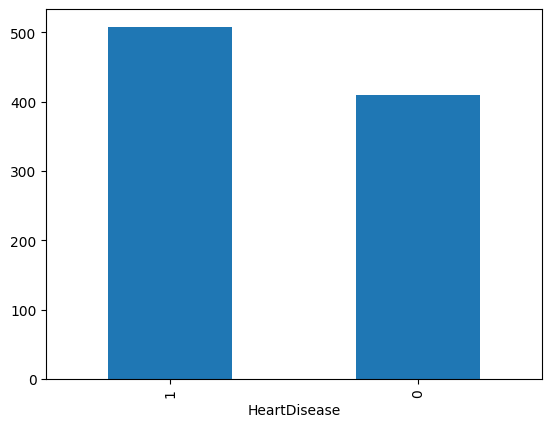

In [11]:
data['HeartDisease'].value_counts().plot(kind = 'bar')

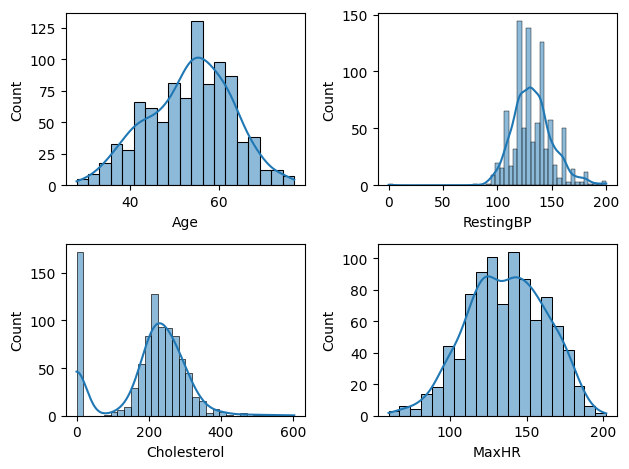

In [12]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(data[var],kde = True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

In [13]:
ch_mean = data.loc[data['Cholesterol'] != 0,'Cholesterol'].mean()

In [14]:
ch_mean

np.float64(244.6353887399464)

In [15]:
data['Cholesterol'] = data['Cholesterol'].replace(0,ch_mean)
data['Cholesterol'] = data['Cholesterol'].round(2)

In [16]:
resting_bp_mean = data.loc[data['RestingBP'] != 0,'RestingBP'].mean()
data['RestingBP'] = data['RestingBP'].replace(0,resting_bp_mean)
data['RestingBP'] = data['RestingBP'].round(2)

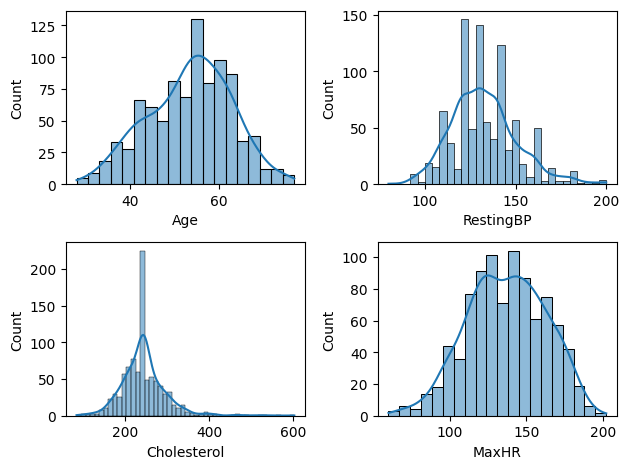

In [17]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(data[var],kde = True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

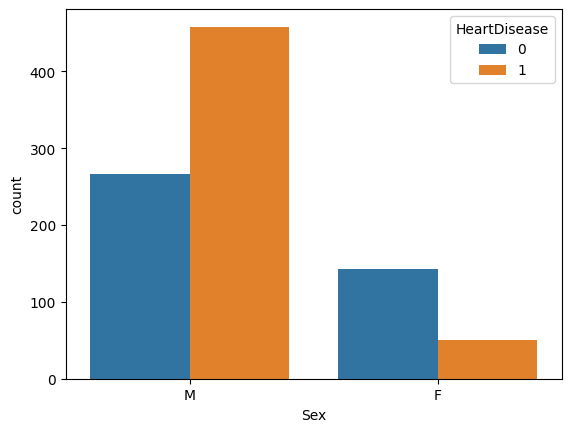

In [18]:
sns.countplot(x =data['Sex'],hue = data['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

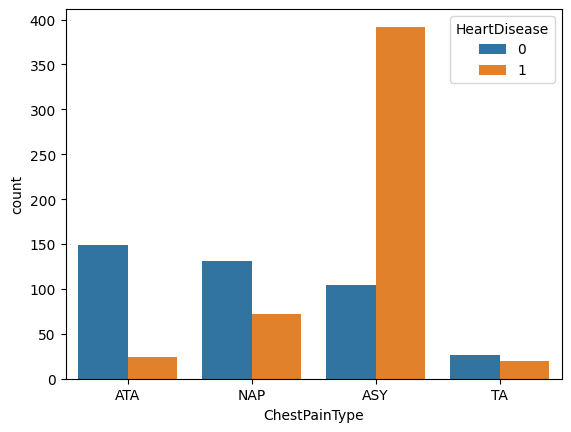

In [19]:
sns.countplot(x = data['ChestPainType'],hue = data['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

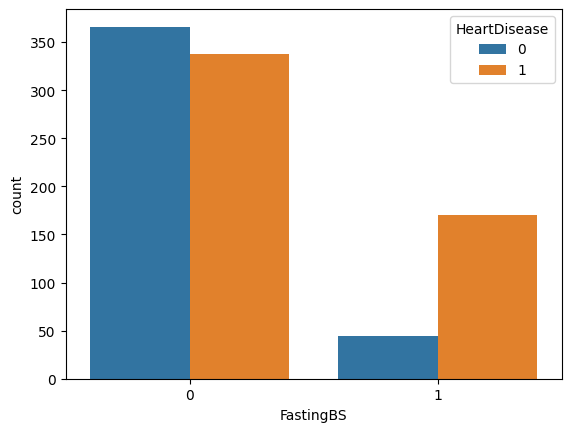

In [20]:
sns.countplot(x = data['FastingBS'],hue = data['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

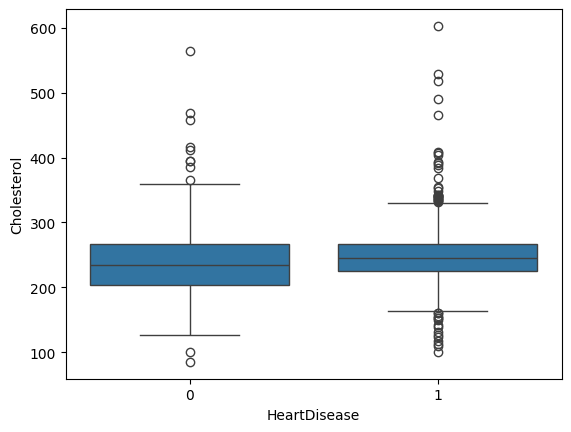

In [21]:
sns.boxplot(x = 'HeartDisease',y = 'Cholesterol',data = data)

<Axes: xlabel='HeartDisease', ylabel='Age'>

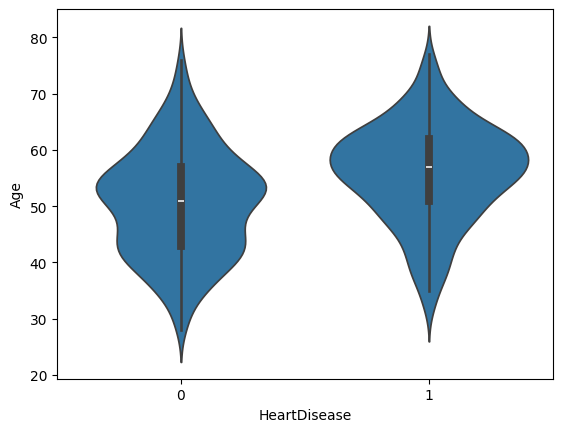

In [22]:
sns.violinplot(x = 'HeartDisease', y ='Age', data=data)

<Axes: >

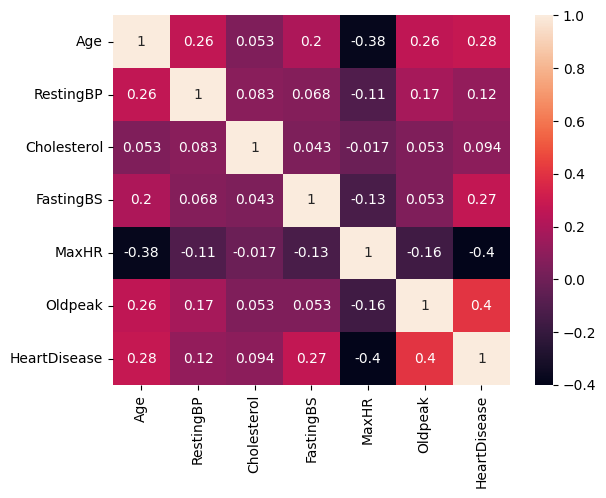

In [23]:
sns.heatmap(data.corr(numeric_only = True),annot = True)

## Data preprocessing and Cleaning

In [24]:
data_encode = pd.get_dummies(data,drop_first=True)

In [25]:
data_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [26]:
data_encode = data_encode.astype(int)

In [27]:
data_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [28]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
data_encode[numerical_cols] = scaler.fit_transform(data_encode[numerical_cols])
data_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


## Model Building

In [29]:
X = data_encode.drop('HeartDisease',axis=1)
y = data_encode['HeartDisease']

In [30]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,roc_curve

### Logistic Regression

In [32]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train,y_train)
pred_lr = model_lr.predict(X_test)
proba_lr = model_lr.predict_proba(X_test)[:,1]

print("Accuracy :",accuracy_score(y_test,pred_lr))
print("Precision :",precision_score(y_test,pred_lr))
print("Recall :",recall_score(y_test,pred_lr))
print("F1 Score :",f1_score(y_test,pred_lr))
print("ROC AUC :",roc_auc_score(y_test,proba_lr))

Accuracy : 0.8804347826086957
Precision : 0.8921568627450981
Recall : 0.8921568627450981
F1 Score : 0.8921568627450981
ROC AUC : 0.9332855093256816


### Decision Tree

In [33]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train,y_train)
pred_dt = model_dt.predict(X_test)
proba_dt = model_dt.predict_proba(X_test)[:,1]

print("Accuracy :",accuracy_score(y_test,pred_dt))
print("Precision :",precision_score(y_test,pred_dt))
print("Recall :",recall_score(y_test,pred_dt))
print("F1 Score :",f1_score(y_test,pred_dt))
print("ROC AUC :",roc_auc_score(y_test,proba_dt))

Accuracy : 0.7554347826086957
Precision : 0.8064516129032258
Recall : 0.7352941176470589
F1 Score : 0.7692307692307693
ROC AUC : 0.7578909612625538


### Random Forest

In [34]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train,y_train)
pred_rf = model_rf.predict(X_test)
proba_rf = model_rf.predict_proba(X_test)[:,1]

print("Accuracy :",accuracy_score(y_test,pred_rf))
print("Precision :",precision_score(y_test,pred_rf))
print("Recall :",recall_score(y_test,pred_rf))
print("F1 Score :",f1_score(y_test,pred_rf))
print("ROC AUC :",roc_auc_score(y_test,proba_rf))

Accuracy : 0.8804347826086957
Precision : 0.8846153846153846
Recall : 0.9019607843137255
F1 Score : 0.8932038834951457
ROC AUC : 0.9302367288378767


### SVM

In [35]:
model_svm = SVC(probability=True,random_state=42)
model_svm.fit(X_train,y_train)
pred_svm = model_svm.predict(X_test)
proba_svm = model_svm.predict_proba(X_test)[:,1]

print("Accuracy :",accuracy_score(y_test,pred_svm))
print("Precision :",precision_score(y_test,pred_svm))
print("Recall :",recall_score(y_test,pred_svm))
print("F1 Score :",f1_score(y_test,pred_svm))
print("ROC AUC :",roc_auc_score(y_test,proba_svm))

Accuracy : 0.8641304347826086
Precision : 0.8811881188118812
Recall : 0.8725490196078431
F1 Score : 0.8768472906403941
ROC AUC : 0.9347202295552368


### KNN

In [36]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train,y_train)
pred_knn = model_knn.predict(X_test)
proba_knn = model_knn.predict_proba(X_test)[:,1]

print("Accuracy :",accuracy_score(y_test,pred_knn))
print("Precision :",precision_score(y_test,pred_knn))
print("Recall :",recall_score(y_test,pred_knn))
print("F1 Score :",f1_score(y_test,pred_knn))
print("ROC AUC :",roc_auc_score(y_test,proba_knn))

Accuracy : 0.8532608695652174
Precision : 0.8640776699029126
Recall : 0.8725490196078431
F1 Score : 0.8682926829268293
ROC AUC : 0.9270683883309422


### XGBoost

In [37]:
model_xgb = XGBClassifier(eval_metric='logloss',random_state=42)
model_xgb.fit(X_train,y_train)
pred_xgb = model_xgb.predict(X_test)
proba_xgb = model_xgb.predict_proba(X_test)[:,1]

print("Accuracy :",accuracy_score(y_test,pred_xgb))
print("Precision :",precision_score(y_test,pred_xgb))
print("Recall :",recall_score(y_test,pred_xgb))
print("F1 Score :",f1_score(y_test,pred_xgb))
print("ROC AUC :",roc_auc_score(y_test,proba_xgb))

Accuracy : 0.8315217391304348
Precision : 0.8585858585858586
Recall : 0.8333333333333334
F1 Score : 0.845771144278607
ROC AUC : 0.9116451458632233


## Model Comparison

In [38]:
model_names = ['Logistic Regression','Decision Tree','Random Forest','SVM','KNN','XGBoost']
predictions = [pred_lr,pred_dt,pred_rf,pred_svm,pred_knn,pred_xgb]
probabilities = [proba_lr,proba_dt,proba_rf,proba_svm,proba_knn,proba_xgb]

acc_list = [accuracy_score(y_test,p) for p in predictions]
prec_list = [precision_score(y_test,p) for p in predictions]
rec_list = [recall_score(y_test,p) for p in predictions]
f1_list = [f1_score(y_test,p) for p in predictions]
auc_list = [roc_auc_score(y_test,p) for p in probabilities]

comparison = pd.DataFrame({
    'Model':model_names,
    'Accuracy':acc_list,
    'Precision':prec_list,
    'Recall':rec_list,
    'F1 Score':f1_list,
    'ROC AUC':auc_list
})

comparison = comparison.sort_values('ROC AUC',ascending=False).reset_index(drop=True)
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,SVM,0.864130,0.881188,0.872549,0.876847,0.934720
1,Logistic Regression,0.880435,0.892157,0.892157,0.892157,0.933286
2,Random Forest,0.880435,0.884615,0.901961,0.893204,0.930237
3,KNN,0.853261,0.864078,0.872549,0.868293,0.927068
4,XGBoost,0.831522,0.858586,0.833333,0.845771,0.911645
5,Decision Tree,0.755435,0.806452,0.735294,0.769231,0.757891


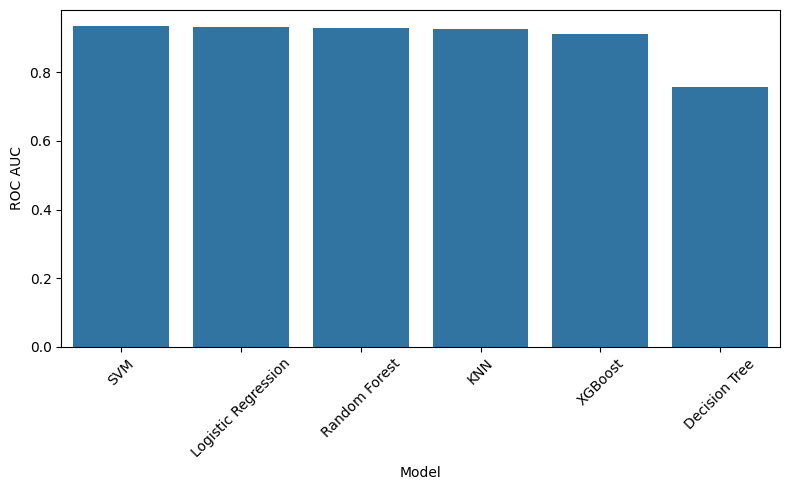

In [39]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model',y='ROC AUC',data=comparison)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cross Validation

In [40]:
cv_lr = cross_val_score(model_lr,X,y,cv=5,scoring='roc_auc').mean()
cv_dt = cross_val_score(model_dt,X,y,cv=5,scoring='roc_auc').mean()
cv_rf = cross_val_score(model_rf,X,y,cv=5,scoring='roc_auc').mean()
cv_svm = cross_val_score(model_svm,X,y,cv=5,scoring='roc_auc').mean()
cv_knn = cross_val_score(model_knn,X,y,cv=5,scoring='roc_auc').mean()
cv_xgb = cross_val_score(model_xgb,X,y,cv=5,scoring='roc_auc').mean()

cv_scores = [cv_lr,cv_dt,cv_rf,cv_svm,cv_knn,cv_xgb]
print("Logistic Regression CV ROC AUC :",cv_lr)
print("Decision Tree CV ROC AUC :",cv_dt)
print("Random Forest CV ROC AUC :",cv_rf)
print("SVM CV ROC AUC :",cv_svm)
print("KNN CV ROC AUC :",cv_knn)
print("XGBoost CV ROC AUC :",cv_xgb)


Logistic Regression CV ROC AUC : 0.9133405306097323
Random Forest CV ROC AUC : 0.8997093862901355
SVM CV ROC AUC : 0.9040259764857405
XGBoost CV ROC AUC : 0.8714845803088199


In [ ]:
cv_map = dict(zip(model_names,cv_scores))
comparison['CV ROC AUC'] = comparison['Model'].map(cv_map)
comparison


## Confusion Matrices

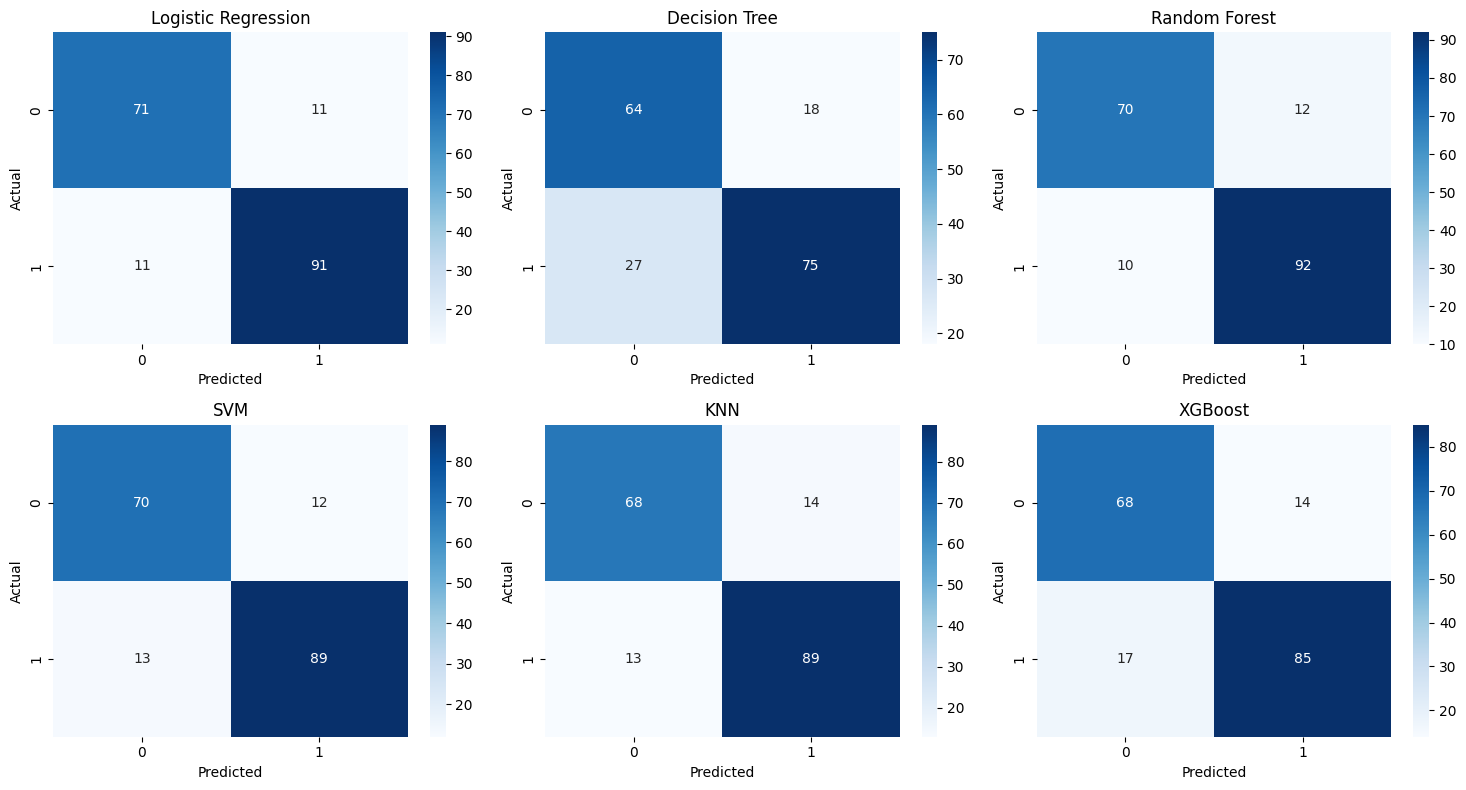

In [41]:
fig,axes = plt.subplots(2,3,figsize=(15,8))

models_for_cm = [pred_lr,pred_dt,pred_rf,pred_svm,pred_knn,pred_xgb]

for i,ax in enumerate(axes.flatten()):
    cm = confusion_matrix(y_test,models_for_cm[i])
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax)
    ax.set_title(model_names[i])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## ROC Curves

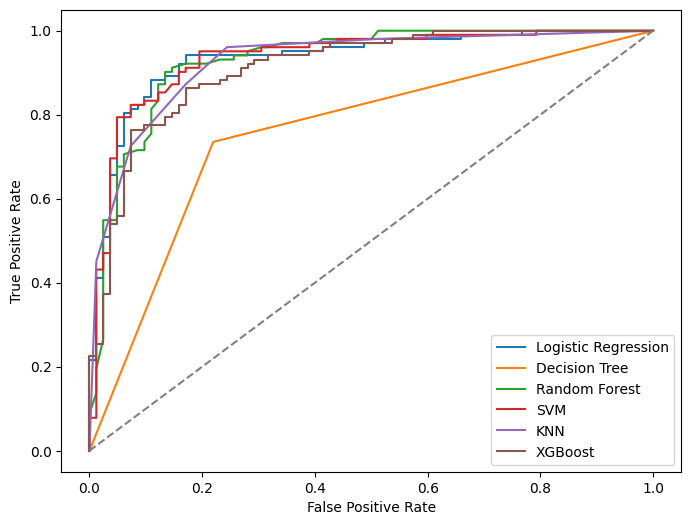

In [42]:
plt.figure(figsize=(8,6))

for name,proba in zip(model_names,probabilities):
    fpr,tpr,_ = roc_curve(y_test,proba)
    plt.plot(fpr,tpr,label=name)

plt.plot([0,1],[0,1],linestyle='--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## Feature Importance

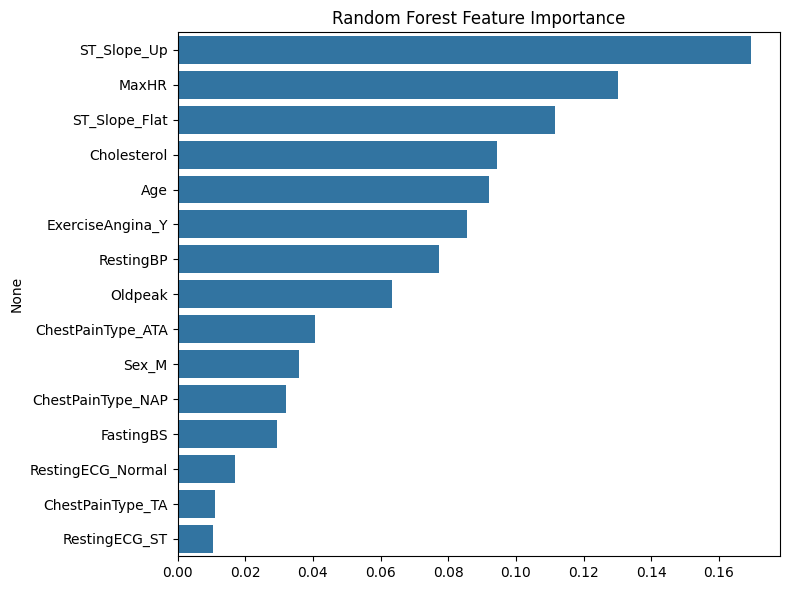

In [43]:
importance_rf = pd.Series(model_rf.feature_importances_,index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importance_rf.values,y=importance_rf.index)
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

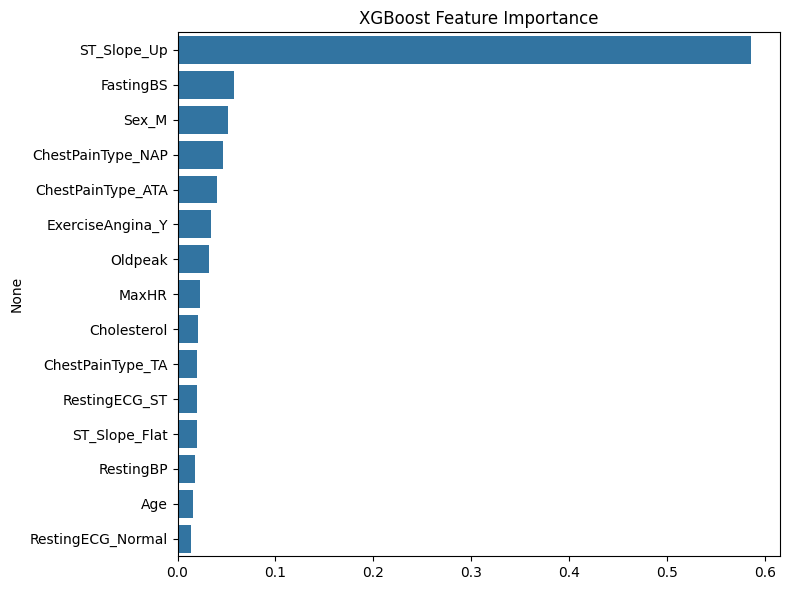

In [44]:
importance_xgb = pd.Series(model_xgb.feature_importances_,index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importance_xgb.values,y=importance_xgb.index)
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

## Final Model Selection

In [45]:
best_model_name = comparison.iloc[0]['Model']
print("Best Model :",best_model_name)

Best Model : SVM


In [46]:
model_map = {
    'Logistic Regression':model_lr,
    'Decision Tree':model_dt,
    'Random Forest':model_rf,
    'SVM':model_svm,
    'KNN':model_knn,
    'XGBoost':model_xgb
}

final_model = model_map[best_model_name]

## SHAP Analysis

In [47]:
if best_model_name in ['Random Forest','XGBoost']:
    shap_model = final_model
    shap_model_name = best_model_name
else:
    shap_model = model_rf
    shap_model_name = 'Random Forest'

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values,list):
    shap_values_class1 = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    shap_values_class1 = shap_values[:,:,1]
else:
    shap_values_class1 = shap_values


In [ ]:
print("SHAP Model :",shap_model_name)


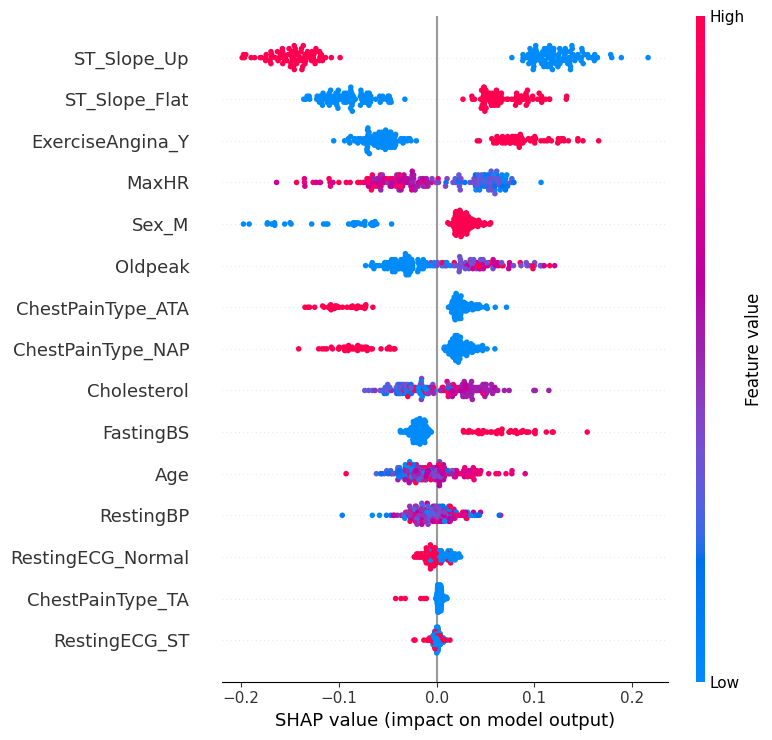

In [48]:
shap.summary_plot(shap_values_class1,X_test)

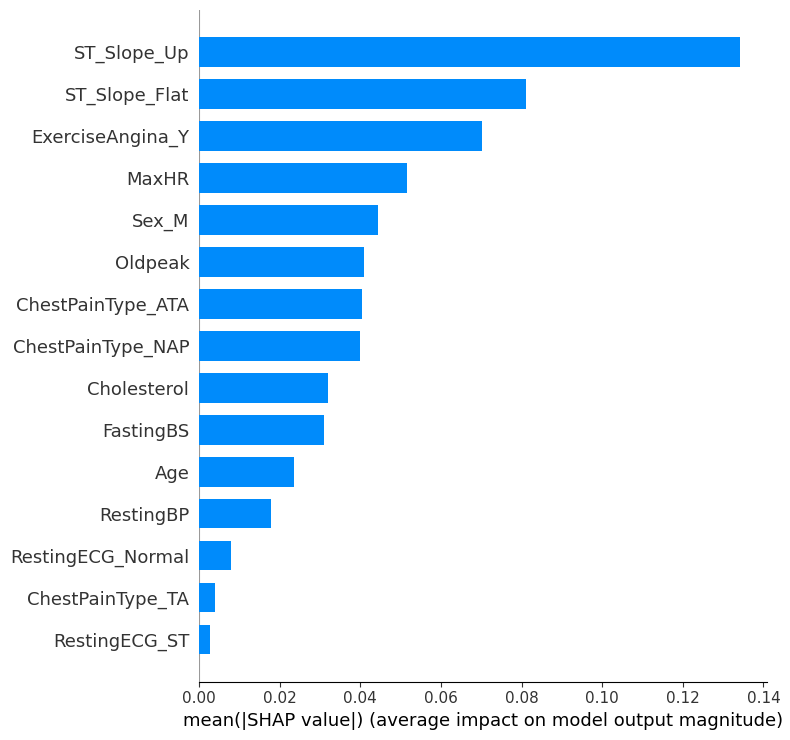

In [49]:
shap.summary_plot(shap_values_class1,X_test,plot_type='bar')

## Save Model

In [50]:
import joblib

joblib.dump(final_model,'heart_model.pkl')
joblib.dump(scaler,'heart_scaler.pkl')
joblib.dump(list(X.columns),'heart_columns.pkl')
joblib.dump(numerical_cols,'heart_numerical_cols.pkl')
joblib.dump(model_rf,'heart_rf_model.pkl')
joblib.dump(shap_model,'heart_shap_model.pkl')
comparison.to_csv('heart_model_comparison.csv',index=False)
